# Dataset -> IBM Argument Quality Dataset

### Goal: to understand argument quality scores and text characteristics.

## Load Dataset

In [4]:
from datasets import load_dataset
import pandas as pd 

ds = load_dataset("ibm-research/argument_quality_ranking_30k", "argument_quality_ranking")

df = pd.DataFrame(ds["train"])

df.head()

,argument,topic,set,WA,MACE-P,stance_WA,stance_WA_conf
0,"""marriage"" isn't keeping up with the times. a...",We should abandon marriage,train,0.846165,0.297659,1,1.000000
1,.a multi-party system would be too confusing a...,We should adopt a multi-party system,train,0.891271,0.726133,-1,1.000000
2,`people reach their limit when it comes to the...,Assisted suicide should be a criminal offence,train,0.730395,0.225212,-1,1.000000
3,"100% agree, should they do that, it would be a...",We should abolish safe spaces,train,0.236686,0.004104,1,0.805517
4,A ban on naturopathy creates a cohesive front ...,We should ban naturopathy,train,0.753805,0.337724,1,1.000000


In [27]:
## Saving a csv copy of the dataset for easier access in the future
df.to_csv("argument_quality_dataset.csv", index=False)

In [5]:
## Shape of dataset

df.shape

(20974, 7)

### Inference:

The dataset have 20974 rows and 7 columns.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20974 entries, 0 to 20973
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   argument        20974 non-null  object 
 1   topic           20974 non-null  object 
 2   set             20974 non-null  object 
 3   WA              20974 non-null  float64
 4   MACE-P          20974 non-null  float64
 5   stance_WA       20974 non-null  int64  
 6   stance_WA_conf  20974 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.1+ MB


### Inference:

The dataset has 3 text based columns and 4 numeric columns.

In [7]:
df.columns

Index(['argument', 'topic', 'set', 'WA', 'MACE-P', 'stance_WA',
       'stance_WA_conf'],
      dtype='object')

### Inference:

| Column             | Description                                                 | Interpretation for Analysis                                                           |
| ------------------ | ----------------------------------------------------------- | ------------------------------------------------------------------------------------- |
| **argument**       | Text content of the argument.                               | Serves as the primary input for NLP models to analyze argument quality and structure. |
| **topic**          | Debate topic associated with the argument.                  | Enables topic-wise analysis of argument quality and stance distribution.              |
| **set**            | Dataset split indicator (train/dev/test).                   | Ensures proper training and evaluation without data leakage.                          |
| **WA**             | Weighted average quality score from human annotations.      | Used as the target variable for argument quality prediction tasks.                    |
| **MACE-P**         | Reliability score computed using the MACE algorithm.        | Indicates confidence in annotation quality and labeling consistency.                  |
| **stance_WA**      | Stance of the argument with respect to the topic (pro/con). | Useful for analyzing how argument quality varies across opposing viewpoints.          |
| **stance_WA_conf** | Confidence score of the stance annotation.                  | Helps evaluate the reliability of stance labels in the dataset.                       |


***********************************************************************************************************************
> The dataset combines textual arguments with quality scores, stance annotations, and reliability metrics, enabling comprehensive analysis of argument strength and argumentative behavior across debate topics.


In [8]:
df.nunique()

argument          20973
topic                49
set                   1
WA                15140
MACE-P            18708
stance_WA             2
stance_WA_conf     5755
dtype: int64

**Inference:**

The data set has **20,973 unique arguments across 49 topics**, suggesting that the debate content is varied. The stances are **binary**, whereas quality and confidence scores are **highly variable**, suggesting variability in argument strength and reliability.

In [9]:
### Checking missing values

df.isnull().sum()

argument          0
topic             0
set               0
WA                0
MACE-P            0
stance_WA         0
stance_WA_conf    0
dtype: int64

### Inference:

No null values present in the dataset.

## Topic Distribution

In [11]:
df["topic"].value_counts().head(10)

topic
We should fight for the abolition of nuclear weapons    554
We should ban naturopathy                               540
Foster care brings more harm than good                  538
We should legalize prostitution                         504
We should ban cosmetic surgery for minors               502
We should legalize polygamy                             500
We should end mandatory retirement                      484
We should abolish capital punishment                    470
We should end affirmative action                        456
We should oppose collectivism                           454
Name: count, dtype: int64

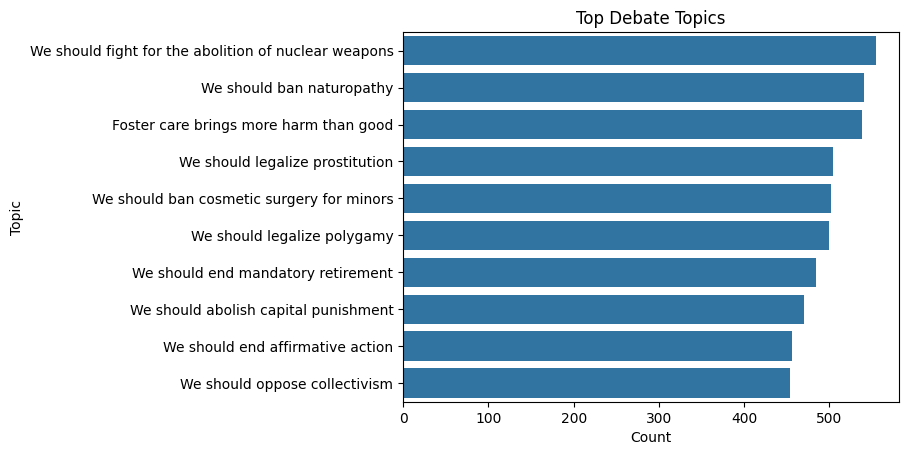

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    y=df["topic"],
    order=df["topic"].value_counts().index[:10]
)

plt.title("Top Debate Topics")
plt.xlabel("Count")
plt.ylabel("Topic")
plt.show()

**Inference:**

The dataset covers multiple debate topics with **relatively similar argument counts**, with the topic *“We should fight for the abolition of nuclear weapons”* having the highest number of arguments. Overall, the distribution across topics appears **fairly balanced**, ensuring diverse argumentative coverage.


## Stance Distribution

In [13]:
df["stance_WA"].value_counts()

stance_WA
 1    10648
-1    10326
Name: count, dtype: int64

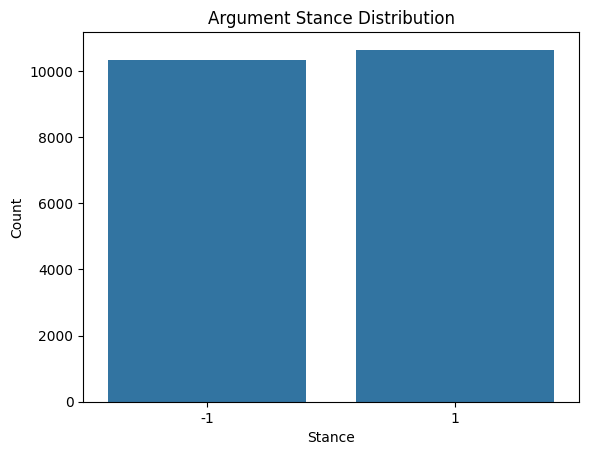

In [14]:
sns.countplot(x=df["stance_WA"])

plt.title("Argument Stance Distribution")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.show()

**Inference:**

The stance distribution is **nearly balanced**, with similar counts for both opposing viewpoints (−1 and 1). This balanced representation ensures that models trained on the dataset will not be biased toward a particular stance.


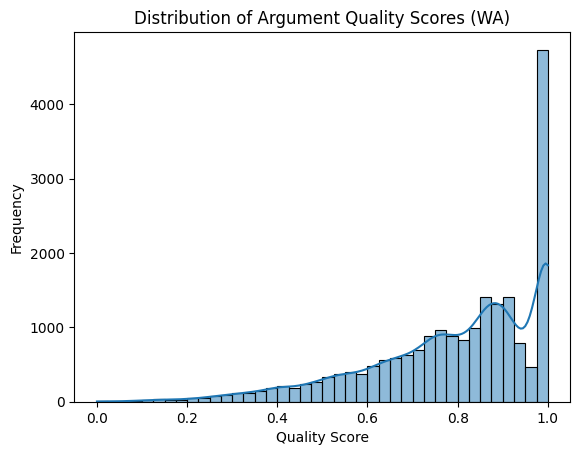

In [26]:
sns.histplot(df["WA"], bins=40, kde=True)

plt.title("Distribution of Argument Quality Scores (WA)")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

### Inference:

- The distribution of argument quality scores shows a wide spread across the scale, indicating significant variation in argument strength. This variability makes the dataset suitable for training models to distinguish between high-quality and low-quality arguments.

## Annotation Reliability (MACE-P)

In [15]:
df["MACE-P"].describe()

count    2.097400e+04
mean     5.707986e-01
std      3.680238e-01
min      5.430000e-14
25%      1.792709e-01
50%      6.868957e-01
75%      9.167528e-01
max      9.999999e-01
Name: MACE-P, dtype: float64

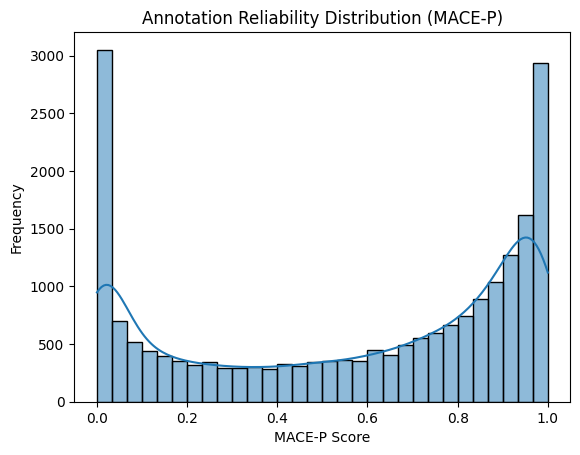

In [16]:
sns.histplot(df["MACE-P"], bins=30, kde=True)

plt.title("Annotation Reliability Distribution (MACE-P)")
plt.xlabel("MACE-P Score")
plt.ylabel("Frequency")
plt.show()

**Inference:**

The MACE-P scores show **wide variability**, ranging from near 0 to 1, with many annotations having **high reliability (scores close to 1)**. This indicates that a large portion of the argument quality annotations are **highly consistent and trustworthy**, while a smaller portion has lower agreement among annotators.


## Text Length Analysis

In [17]:
df["char_length"] = df["argument"].apply(len)

df["word_count"] = df["argument"].apply(lambda x: len(x.split()))

In [18]:
df["word_count"].describe()

count    20974.000000
mean        18.180509
std          7.577671
min          4.000000
25%         12.000000
50%         17.000000
75%         23.000000
max         44.000000
Name: word_count, dtype: float64

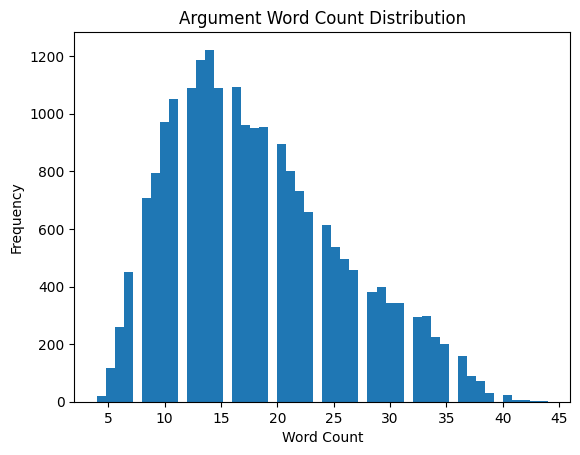

In [19]:
plt.hist(df["word_count"], bins=50)

plt.title("Argument Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

**Inference:**

Most arguments are **short to medium in length**, with an average of about **18 words per argument**. The distribution shows that the majority fall between **12 and 23 words**, indicating that arguments are generally concise textual statements.


## Quality vs Argument Length

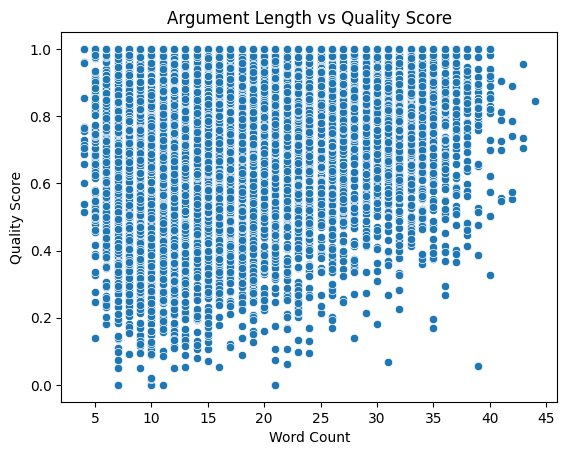

In [20]:
sns.scatterplot(
    x=df["word_count"],
    y=df["WA"]
)

plt.title("Argument Length vs Quality Score")
plt.xlabel("Word Count")
plt.ylabel("Quality Score")
plt.show()

**Inference:**

The scatter plot shows a **slight positive trend** between argument length and quality score, suggesting that **longer arguments tend to have higher quality scores**, although the relationship is not very strong and quality varies across different lengths.


## Stance vs Quality

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


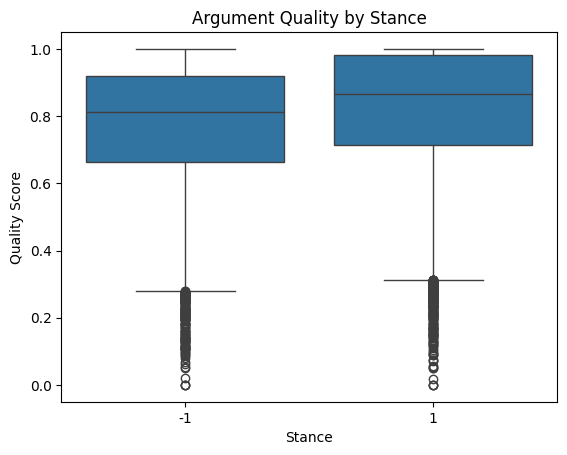

In [21]:
sns.boxplot(
    x=df["stance_WA"],
    y=df["WA"]
)

plt.title("Argument Quality by Stance")
plt.xlabel("Stance")
plt.ylabel("Quality Score")
plt.show()

**Inference:**

Both stances exhibit **similar quality score distributions**, indicating that argument quality is **not strongly dependent on the stance (pro or con)**. High-quality arguments appear across both viewpoints.


## Vocabulary Analysis

In [22]:
from collections import Counter

all_words = " ".join(df["argument"].astype(str)).split()

vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))
print(vocab.most_common(20))

Vocabulary size: 17670
[('to', 15479), ('the', 13398), ('and', 11025), ('a', 8823), ('is', 8533), ('of', 8184), ('be', 7072), ('should', 6671), ('it', 5255), ('for', 4914), ('in', 4804), ('not', 4768), ('people', 4325), ('are', 4240), ('we', 4118), ('that', 3949), ('they', 3458), ('because', 3066), ('their', 3056), ('have', 2885)]


**Inference:**

The dataset contains a **large and diverse vocabulary (~17.6K unique words)**, indicating rich linguistic variation. The most frequent terms are **common stopwords**, suggesting that preprocessing such as stopword removal may be beneficial for downstream modeling.

## Clean Vocabulary

In [23]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

clean_words = [
    w for w in all_words
    if w.lower() not in stop_words and w.isalpha()
]

print("Clean vocabulary size:", len(set(clean_words)))

Clean vocabulary size: 10729


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Inference:**

After removing stopwords and non-alphabetic tokens, the dataset still retains a **large vocabulary (~10.7K unique words)**, indicating substantial lexical diversity suitable for training robust NLP models.


## Extreme Arguments

In [24]:
### Highest quality arguments

df.sort_values("WA", ascending=False)[["argument", "topic", "WA"]].head()

,argument,topic,WA
16974,vocational education provides valuable trainin...,We should subsidize vocational education,1.0
3390,economic sanctions affect the poorest in the c...,We should end the use of economic sanctions,1.0
3414,economic sanctions are an effective deterrent ...,We should end the use of economic sanctions,1.0
11267,polygamy encourages the idea that women are co...,We should legalize polygamy,1.0
3410,economic sanctions are a way to implement sanc...,We should end the use of economic sanctions,1.0


In [25]:
### Lowest quality arguments

df.sort_values("WA")[["argument", "topic", "WA"]].head()

,argument,topic,WA
6481,if it is allowed in certain countries it is th...,We should abolish the right to keep and bear arms,0.0
10388,old habit is hard to break even against it's m...,We should adopt a multi-party system,0.0
15015,the parents who stay at home tell us that what...,We should subsidize stay-at-home dads,0.0
3306,"decide when moorir should be a crime, no matte...",Assisted suicide should be a criminal offence,0.0
8548,legalize poligamy and i need the house,We should legalize polygamy,0.0


**Inference:**

High-quality arguments generally contain clearer reasoning and stronger claims, whereas low-quality arguments tend to be shorter and less structured.


# Key Insights

### 1. Dataset Diversity

The dataset contains **over 20K unique arguments across 49 debate topics**, indicating diverse argumentative content suitable for training argument quality models.

---

### 2. Topic Distribution

While the dataset covers multiple debate topics, a few topics appear more frequently, suggesting a **slight imbalance in topic representation**.

---

### 3. Stance Distribution

Arguments are labeled with **two possible stances (pro and con)**. The distribution appears relatively balanced, allowing analysis of argument quality across opposing viewpoints.

---

### 4. Annotation Reliability

The **MACE-P scores show high variability**, reflecting different levels of annotation confidence and reliability across arguments.

---

### 5. Argument Length

Most arguments are **short textual spans consisting of a few sentences**, making them suitable for transformer-based NLP models.

---

### 6. Argument Length vs Quality

There is a **weak positive relationship between argument length and quality score**, suggesting that longer arguments may provide more detailed reasoning.

---

### 7. Stance vs Argument Quality

The distribution of quality scores across stance categories indicates that **argument strength is not strongly dependent on stance**, meaning both pro and con arguments can achieve high quality.

---

### 8. Vocabulary Richness

Vocabulary analysis shows a **large number of unique tokens**, demonstrating linguistic diversity in argumentative expressions.

---

### 9. Argument Quality Range

The presence of both high-quality and low-quality arguments indicates that the dataset provides **good variation for training argument quality prediction models**.